# Notebook 92 — second detector branch from sparse false negatives

This notebook splits the 121 oracle false negatives left by notebook 91's sparse detector into subclasses, learns a second Python-only branch, and tests two-branch unions downstream.

In [1]:
from pathlib import Path
import subprocess
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_second_branch_detector.py'
OUT = ROOT / 'results' / 'notebook92_second_branch_detector'
SCRIPT, OUT

(PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_second_branch_detector.py'),
 PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector'))

In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
print(completed.returncode)

Loading cached localmax entries from /Users/grosbedou/PycharmProjects/NDORMS/results/notebook90_conditional_hough_patch/angle_profile_localmax_entries.pkl
Evaluating notebook 92 variant: baseline_current
Evaluating notebook 92 variant: oracle_overweight_to_localmax
Evaluating notebook 92 variant: nb90_mass10_gap4_reference
Evaluating notebook 92 variant: branch1_sparse_only
Evaluating notebook 92 variant: branch1_plus_branch2_precision
Evaluating notebook 92 variant: branch1_plus_branch2_coverage
# Notebook 92 — second detector branch from sparse false negatives

This notebook takes the 121 oracle false negatives left by notebook 91's sparse detector,
splits them into subclasses, learns a second Python-only branch on the dominant subclass structure,
and replays sparse-branch unions through persistence and downstream parity.

## Remaining sparse-miss subclasses

- displaced_topfamily_nonlower: 72 frames
- selected_topfamily_residual: 33 frames
- displaced_topfamily_lower_dominant: 16 fr

In [3]:
display(Markdown((OUT / 'notebook92_summary.md').read_text()))

# Notebook 92 — second detector branch from sparse false negatives

This notebook takes the 121 oracle false negatives left by notebook 91's sparse detector,
splits them into subclasses, learns a second Python-only branch on the dominant subclass structure,
and replays sparse-branch unions through persistence and downstream parity.

## Remaining sparse-miss subclasses

- displaced_topfamily_nonlower: 72 frames
- selected_topfamily_residual: 33 frames
- displaced_topfamily_lower_dominant: 16 frames

## Learned branch rules

- Branch 1 (fixed sparse rule): `mass_below_10deg >= 0.3 and best_upper_share <= 0.1`
- Branch 2 precision-oriented rule: `selected_is_top_family <= 0 and mass_below_10deg >= 0.18 and gap_to_lower_deg >= 6 and selected_family_share <= 0.12`
- Branch 2 coverage-oriented rule: `selected_is_top_family <= 0 and mass_below_10deg >= 0.18 and gap_to_lower_deg >= 6`

## Key findings

- Two-branch precision union: precision 0.317, recall 0.203, FL RMSE 1.9486 mm.
- Two-branch coverage union: precision 0.290, recall 0.242, FL RMSE 1.7532 mm.
- Best downstream FL among notebook 92 variants is `nb90_mass10_gap4_reference` at 1.2569 mm versus baseline 2.0116 mm.

## Interpretation

- If the two-branch unions improve over sparse-only without collapsing precision, then the sparse misses are at least partly structured and not just detector noise.
- Comparing precision-oriented and coverage-oriented branch 2 rules tells us whether the second branch should stay conservative or whether broader displaced-top-family coverage helps more downstream.

- Subclass CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/remaining_false_negative_subclasses.csv`
- Branch-2 frontier CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/branch2_rule_frontier.csv`
- Selected rules JSON: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/selected_branch_rules.json`
- Combined summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/two_branch_variant_summary.csv`
- Detector stats CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/two_branch_detector_stats.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/two_branch_per_frame.csv`
- Summary figure: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook92_second_branch_detector/two_branch_detector_summary.png`


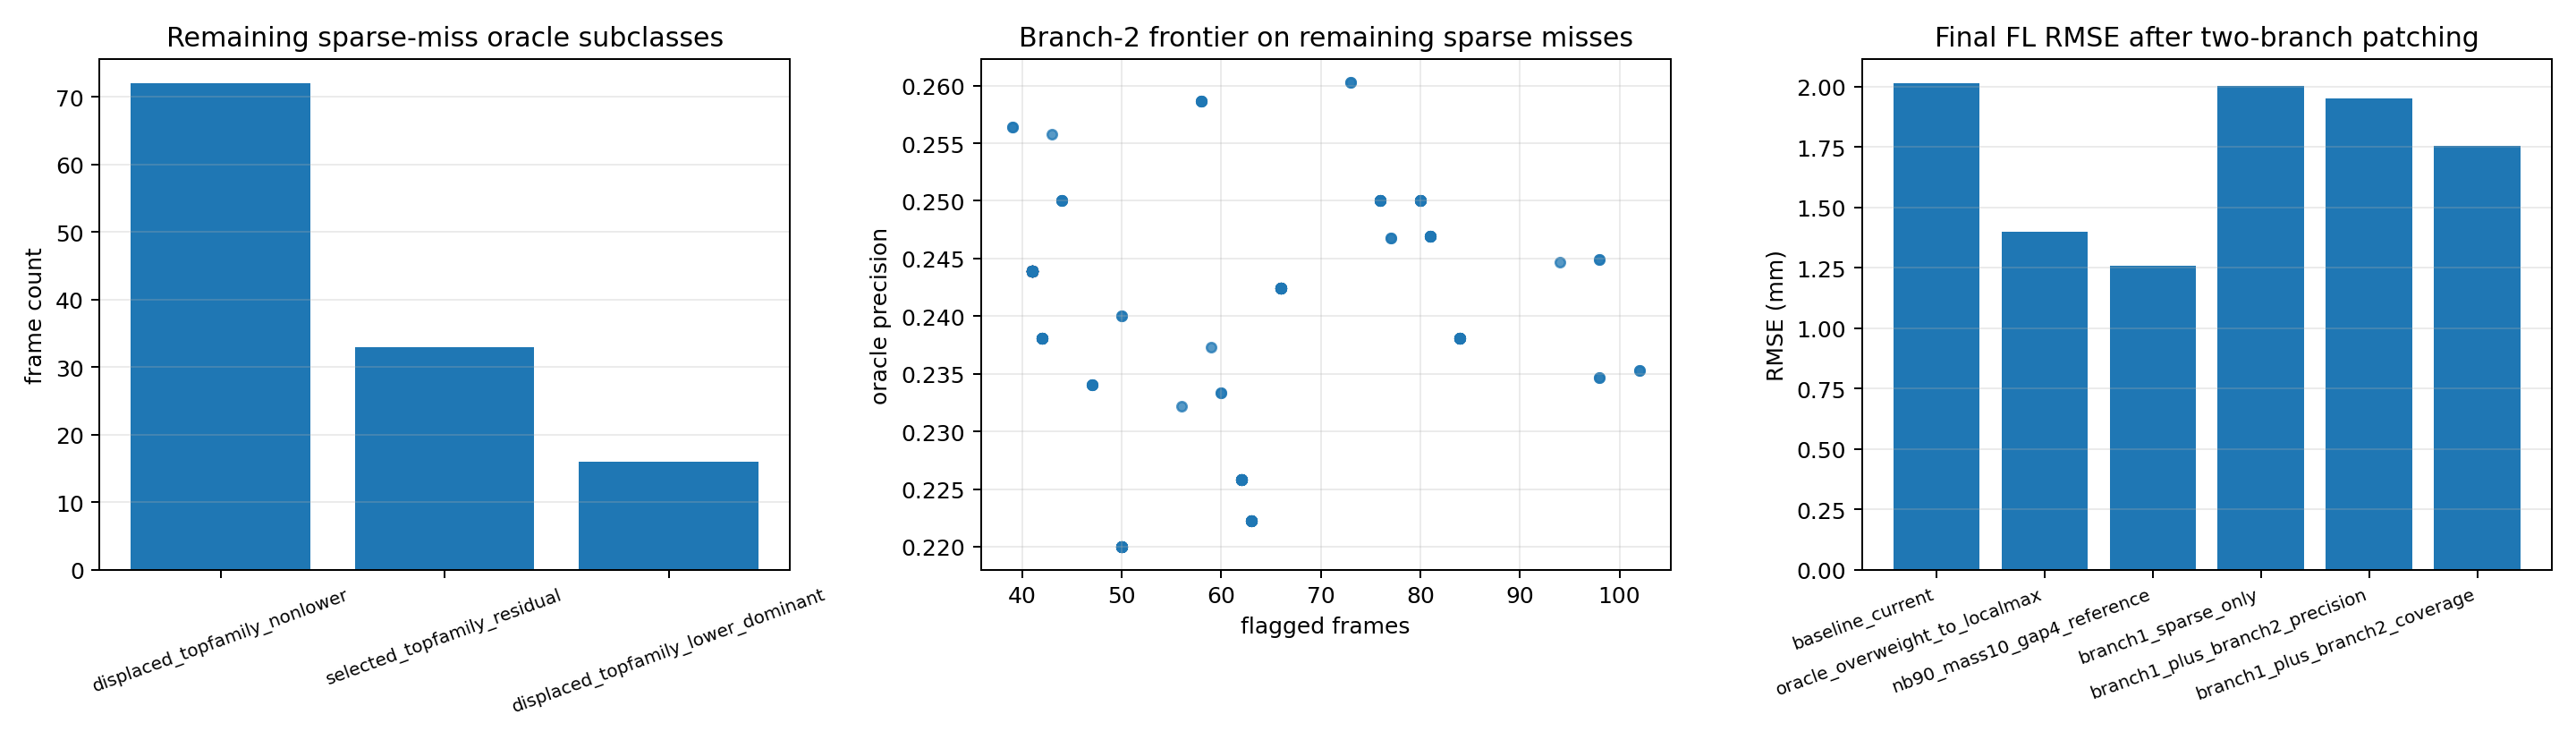

In [4]:
display(Image(filename=str(OUT / 'two_branch_detector_summary.png')))